<a href="https://colab.research.google.com/github/prasithmandara/Weather-Classification/blob/main/Weather_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print('Libraries imported successfully!')

Libraries imported successfully!


In [2]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/GITHUB/weather.csv')
print('Shape:', df.shape)
df.head()

Shape: (50, 3)


,temperature,humidity,weather
0,30,20,sunny
1,32,18,sunny
2,35,15,sunny
3,28,22,sunny
4,31,25,sunny


In [3]:
print('Dataset Info:')
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   temperature  50 non-null     int64 
 1   humidity     50 non-null     int64 
 2   weather      50 non-null     object
dtypes: int64(2), object(1)
memory usage: 1.3+ KB


In [4]:
print('Weather Label Counts:')
print(df['weather'].value_counts())

print('\nBasic Statistics:')
df.describe()

Weather Label Counts:
weather
sunny    25
rainy    25
Name: count, dtype: int64

Basic Statistics:


,temperature,humidity
count,50.000000,50.000000
mean,25.640000,56.480000
std,6.561359,33.458619
min,15.000000,5.000000
25%,20.000000,20.500000
50%,25.000000,65.000000
75%,31.000000,87.750000
max,38.000000,99.000000


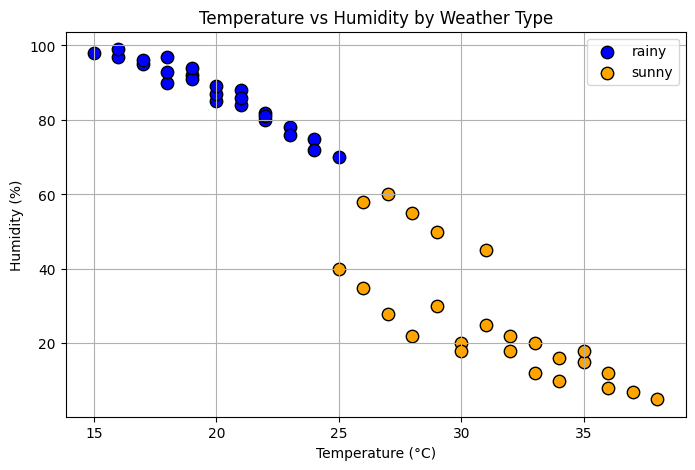

In [5]:
# Scatter plot: Temperature vs Humidity colored by weather
plt.figure(figsize=(8, 5))
colors = {'sunny': 'orange', 'rainy': 'blue'}
for label, group in df.groupby('weather'):
    plt.scatter(group['temperature'], group['humidity'],
                label=label, color=colors[label], s=80, edgecolors='black')

plt.xlabel('Temperature (°C)')
plt.ylabel('Humidity (%)')
plt.title('Temperature vs Humidity by Weather Type')
plt.legend()
plt.grid(True)
plt.show()

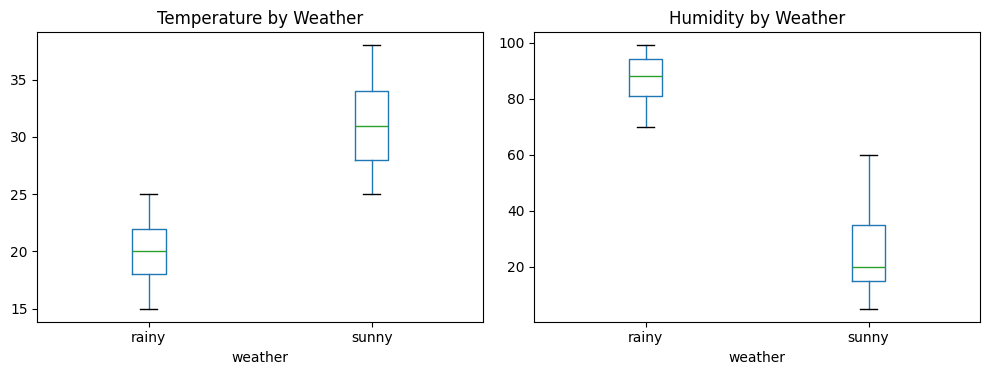

In [6]:
# Boxplots
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df.boxplot(column='temperature', by='weather', ax=axes[0], grid=False)
axes[0].set_title('Temperature by Weather')
df.boxplot(column='humidity', by='weather', ax=axes[1], grid=False)
axes[1].set_title('Humidity by Weather')
plt.suptitle('')
plt.tight_layout()
plt.show()

In [7]:
X = df[['temperature', 'humidity']]
y = df['weather']

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print('Classes:', le.classes_)
print('Encoded:', le.transform(le.classes_))

Classes: ['rainy' 'sunny']
Encoded: [0 1]


In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('Features scaled successfully!')

Features scaled successfully!


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)

print(f'Training samples: {X_train.shape[0]}')
print(f'Testing samples:  {X_test.shape[0]}')

Training samples: 40
Testing samples:  10


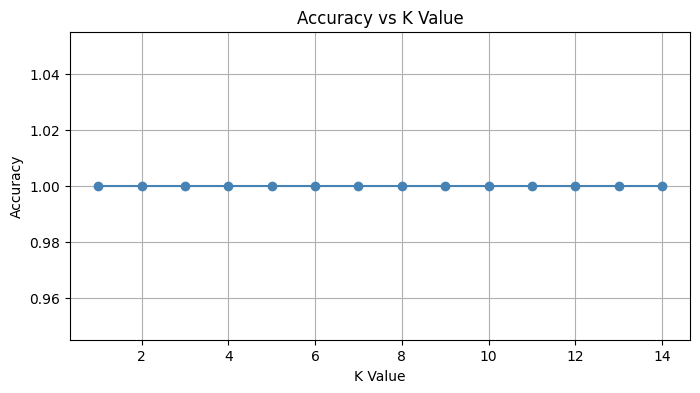

Best K: 1 with Accuracy: 100.00%


In [10]:
accuracies = []
k_range = range(1, 15)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    acc = accuracy_score(y_test, knn.predict(X_test))
    accuracies.append(acc)

plt.figure(figsize=(8, 4))
plt.plot(k_range, accuracies, marker='o', color='steelblue')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.title('Accuracy vs K Value')
plt.grid(True)
plt.show()

best_k = k_range[accuracies.index(max(accuracies))]
print(f'Best K: {best_k} with Accuracy: {max(accuracies)*100:.2f}%')

In [11]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
print('Model trained successfully!')

Model trained successfully!


In [12]:
y_pred = knn.predict(X_test)

print(f'Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=le.classes_))

Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

       rainy       1.00      1.00      1.00         8
       sunny       1.00      1.00      1.00         2

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



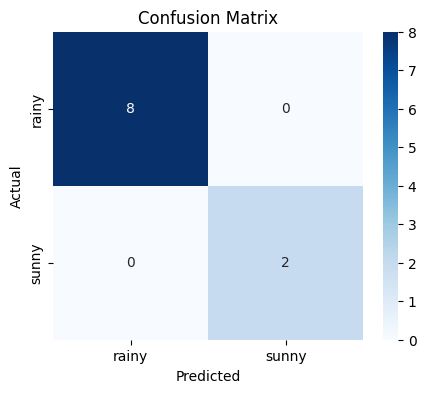

In [13]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [14]:
# [temperature, humidity]
new_samples = [
    [35, 10],   # hot & dry -> Expected: sunny
    [18, 95],   # cold & humid -> Expected: rainy
    [30, 20],   # warm & dry -> Expected: sunny
    [20, 85],   # cool & humid -> Expected: rainy
]

for sample in new_samples:
    scaled = scaler.transform([sample])
    pred = knn.predict(scaled)
    label = le.inverse_transform(pred)[0]
    print(f'Temp={sample[0]}°C, Humidity={sample[1]}%  -->  Predicted: {label.upper()}')

Temp=35°C, Humidity=10%  -->  Predicted: SUNNY
Temp=18°C, Humidity=95%  -->  Predicted: RAINY
Temp=30°C, Humidity=20%  -->  Predicted: SUNNY
Temp=20°C, Humidity=85%  -->  Predicted: RAINY


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
